# 0. Environment and Configuration

In [ ]:
import subprocess
import time
import re
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import os
import workflows
import json
import glob
from plotnine import *

In [ ]:
e4s_cl_path = '/lus/bnchlu1/neth/e4s-cl/install/bin'
go_dir = '/lus/scratch/crickett/go/'
apptainer_bin_path = '/lus/scratch/crickett/software/usr/bin'
apptainer_cache_dir = '/lus/bnchlu1/neth/.local/apptainer/'



workflow_dir = os.getcwd()
workflows.set_workflow_log(f'{workflow_dir}/ampere-workflow.log')

results_df_path = os.path.join(workflow_dir, 'ampere_weak_scaling_results.csv')


# 1. Download and Install Ampere

In [ ]:
os.chdir(workflow_dir)
if not os.path.exists('ampere-repo'):
    workflows.run_cmd('git clone https://github.com/brandon-neth/ampere.git ampere-repo')

os.chdir('ampere-repo')
workflows.run_cmd('pip install .')
os.chdir('..')
import ampere

# 2. Prepare Arkouda Client and e4s-cl Profile

## Clone Setup Repository and Create e4s-cl Profile

In [ ]:
workflows.cd(workflow_dir)
if not os.path.exists('e4s-cl-setup'):
    workflows.run_cmd('git clone https://github.com/arezaii/e4s-cl-setup.git')

output = subprocess.run('e4s-cl profile list', shell=True, check=True, stdout=subprocess.PIPE).stdout.decode('utf-8')
if 'arkouda-container' not in output:
    
    workflows.cd('e4s-cl-setup')
    input = 'y\ny\nn\narkouda-container\n'
    subprocess.run('./setup_all.sh', shell=True, check=True, input=input.encode('utf-8'))
    workflows.cd(workflow_dir)

workflows.run_cmd('e4s-cl profile select arkouda-container')


## Download Arkouda Container

In [ ]:
container_path = os.path.join(workflow_dir, 'chapel-arkouda.sif')

if not os.path.exists(container_path):
    workflows.run_cmd(f'apptainer pull {container_path} docker://arezaiihpe/chapel-2.9.0-arkouda-main-cxi:2.3.1')

workflows.run_cmd(f'e4s-cl profile edit --image {container_path}')


## Prepare Arkouda Client Library

In [ ]:
try:
    import arkouda as ak
except ImportError:
    workflows.cd(workflow_dir)
    # clone with the tag v2025.12.16
    if not os.path.exists('arkouda-repo'):
        workflows.run_cmd('git clone --branch v2025.12.16 https://github.com/Bears-R-Us/arkouda.git arkouda-repo')

    workflows.cd('arkouda-repo')
    workflows.run_cmd('pip install .')
    workflows.cd(workflow_dir)
import arkouda as ak



# 3. Run Weak Scaling Evaluation

## Gather Trace Directories and Arguments

In [83]:
traces_dir = os.path.join(workflow_dir, 'out')

trace_dirs = [os.path.join(traces_dir, d) for d in os.listdir(traces_dir) if os.path.isdir(os.path.join(traces_dir, d))]

trace_maps = [] # list of dicts, each dict contains the trace_dir and the run_args.json contents
for dir in trace_dirs:
    arg_file_path = os.path.join(dir, 'logs/run_args.json')
    if os.path.exists(arg_file_path):
        args = {}
        args['trace_dir'] = dir
        with open(arg_file_path, 'r') as f:
            args.update(json.load(f))
        trial_num = int(re.search(r'trial(\d+)', dir).group(1))
        args['trial_num'] = trial_num
        trace_maps.append(args)

## Define our Topologies and Metrics for Ampere

In [84]:
from ampere import Ensemble, MetricConfig, MetricType, AmpereSession, Visualizer, connect

# Define Metric Configs
configs = {
    re.compile(r".*rocm.*energy.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
    re.compile(r".*rocm.*power.*"): MetricConfig(MetricType.INSTANTANEOUS, scale_factor=1e-6),
}

# Define Topology Resolver
def topology_resolver_generator(node_count, ranks_per_node=8):
    device4_names = [f'MPI Rank {node_idx*ranks_per_node + i}' for i in [0,1] for node_idx in range(node_count)]
    device2_names = [f'MPI Rank {node_idx*ranks_per_node + i}' for i in [2,3] for node_idx in range(node_count)]
    device6_names = [f'MPI Rank {node_idx*ranks_per_node + i}' for i in [4,5] for node_idx in range(node_count)]
    device0_names = [f'MPI Rank {node_idx*ranks_per_node + i}' for i in [6,7] for node_idx in range(node_count)]

    def topology_resolver(metric_name, ranks):
        if 'device=4' in metric_name: return [r for r in ranks if r.name in device4_names]
        if 'device=2' in metric_name: return [r for r in ranks if r.name in device2_names]
        if 'device=6' in metric_name: return [r for r in ranks if r.name in device6_names]
        if 'device=0' in metric_name: return [r for r in ranks if r.name in device0_names]
        return ranks
    return topology_resolver

def topology_generator(node_count, ranks_per_node=8):
    topo = {}
    for node_idx in range(node_count):
        node_name = f'Node{node_idx}'
        ranks = [f'MPI Rank {node_idx*ranks_per_node + i}' for i in range(ranks_per_node)]
        topo[node_name] = ranks
    return topo

## Create our Results DataFrame and File

In [85]:
if os.path.exists(results_df_path):
    results_df = pd.read_csv(results_df_path)
else:
    results_df = pd.DataFrame(columns=['trace_node_count', 'server_node_count', 'sorted', 'trial_num', 'format', 'reading_time', 'attribution_time', 'trace_dir'])


## For Each Trace, Start a Server, Connect, and Run Attribution

In [86]:
def find_server_name_and_port():
    # First check if there's a running slurm job from me with the name "arkouda-server"
    result = subprocess.run('squeue --me --name arkouda-server -t R', shell=True, check=True, stdout=subprocess.PIPE).stdout.decode('utf-8')
    lines = result.strip().split('\n')
    if len(lines) > 1:
        # If there is, extract the job ID and find the node it's running on
        job_id = lines[1].split()[0]
        result = subprocess.run(f'scontrol show job {job_id}', shell=True, check=True, stdout=subprocess.PIPE).stdout.decode('utf-8')
    else:
        print("No slurm job found with name 'arkouda-server'")
        return None

    # Now read the output file for the arkouda server to find the URL
    output_file = f'arkouda_arkouda-server_{job_id}.out'

    # match for *                          server listening on tcp://x1002c2s4b0n0:5555                          *
    pattern = re.compile(r'server listening on (tcp://\S+)')
    try:
        with open(output_file, 'r') as f:
            for line in f:
                match = pattern.search(line)
                if match:
                    url = match.group(1)
                    name,port = url.split('//')[1].split(':')
                    return name, port
    except FileNotFoundError:
        print("No output file for arkouda server job")
        return None
    print("Could not find arkouda server URL in output file")
    return None

In [ ]:
for trace_map in trace_maps:
    trace_dir = trace_map['trace_dir']
    
    print(f'Processing trace {trace_dir}...')
    
    # Check if we've run the conversion on this trace already   
    if results_df[(results_df['trace_dir'] == trace_dir)].shape[0] > 0:
        print(f"Skipping trace {trace_dir} trial {trace_map['trial_num']} because it has already been processed")
        continue

    # Disconnect from the arkouda server if connected
    try:
        ak.disconnect()
    except Exception as e:
        pass
    
    # Start the arkouda server
    server_node_count = trace_map['node_count']
    workflows.run_cmd(f'scancel --me')
    time.sleep(5)
    workflows.run_cmd(f'e4s-cl-setup/bin/launch_arkouda.sh -N {server_node_count}')
    while find_server_name_and_port() is None:
        print("Waiting for arkouda server to start...")
        time.sleep(5)
    server_name, server_port = find_server_name_and_port()

    # Connect to the arkouda server
    connect(server=server_name, port=server_port)

    # Prepare the topology and resolver
    trace_node_count = trace_map['node_count']
    topo = topology_generator(trace_node_count)
    topo_resolver = topology_resolver_generator(trace_node_count)

    start = time.time()
    ensemble = Ensemble.from_trace_paths_parquet([trace_dir], metric_configs=configs, node_ranks=topo)
    reading_time = time.time() - start

    start = time.time()
    ensemble.attribute(
        'A2rocm_smi:::energy_count:device=6',
        topology_resolver=topo_resolver,
        strategy='exclusive'
    ) 
    attribution_time = time.time() - start

    results_df = pd.concat([results_df, pd.DataFrame([{
        'trace_node_count': trace_node_count,
        'server_node_count': server_node_count,
        'sorted': trace_map['sort_callgraph'],
        'trial_num': trace_map['trial_num'],
        'format': trace_map['format'],
        'reading_time': reading_time,
        'attribution_time': attribution_time,
        'trace_dir': trace_dir
    }])], ignore_index=True)

    results_df.to_csv(results_df_path, index=False)

Skipping trace /lus/bnchlu1/neth/fastotf2/workflows/scaling/out/locgroup_dist_block_PARQUET_32nodes_64threads_nosort_trial1 trial 1 because it has already been processed
Skipping trace /lus/bnchlu1/neth/fastotf2/workflows/scaling/out/locgroup_dist_block_PARQUET_8nodes_64threads_nosort_trial1 trial 1 because it has already been processed
Skipping trace /lus/bnchlu1/neth/fastotf2/workflows/scaling/out/locgroup_dist_block_PARQUET_4nodes_64threads_sort_trial1 trial 1 because it has already been processed
Skipping trace /lus/bnchlu1/neth/fastotf2/workflows/scaling/out/locgroup_dist_block_PARQUET_4nodes_64threads_nosort_trial0 trial 0 because it has already been processed
Skipping trace /lus/bnchlu1/neth/fastotf2/workflows/scaling/out/locgroup_dist_block_PARQUET_8nodes_64threads_sort_trial0 trial 0 because it has already been processed
Skipping trace /lus/bnchlu1/neth/fastotf2/workflows/scaling/out/locgroup_dist_block_PARQUET_2nodes_64threads_sort_trial0 trial 0 because it has already been p

/home/users/neth/.local/lib/python3.11/site-packages/arkouda/client.py:858: RuntimeWarning: Version mismatch between client (2025.12.16) and server (0+untagged.1.gd61e151.dirty); this may cause some commands to fail or behave incorrectly! Updating arkouda is strongly recommended.
connected to arkouda server tcp://*:5555


Connecting to Arkouda server at x1003c3s2b0n0:5555...
Starting to load runs...


Loading Runs:   0%|          | 0/1 [00:00<?, ?it/s]

Processing node: Node0 with ranks: ['MPI Rank 0', 'MPI Rank 1', 'MPI Rank 2', 'MPI Rank 3', 'MPI Rank 4', 'MPI Rank 5', 'MPI Rank 6', 'MPI Rank 7']
Reading metrics from: /lus/bnchlu1/neth/fastotf2/workflows/scaling/out/locgroup_dist_block_PARQUET_16nodes_64threads_nosort_trial0/MPI Rank 0_metrics.parquet
metrics file columns:  dict_keys(['group', 'metric_name', 'time', 'value_int', 'value_real'])
Done with metrics from  /lus/bnchlu1/neth/fastotf2/workflows/scaling/out/locgroup_dist_block_PARQUET_16nodes_64threads_nosort_trial0/MPI Rank 0_metrics.parquet
Reading callgraph from  /lus/bnchlu1/neth/fastotf2/workflows/scaling/out/locgroup_dist_block_PARQUET_16nodes_64threads_nosort_trial0/MPI Rank 0_Master_thread_callgraph.parquet
Group value for callgraph /lus/bnchlu1/neth/fastotf2/workflows/scaling/out/locgroup_dist_block_PARQUET_16nodes_64threads_nosort_trial0/MPI Rank 0_Master_thread_callgraph.parquet: MPI Rank 0
Reading callgraph from  /lus/bnchlu1/neth/fastotf2/workflows/scaling/out/l

...

Loading Runs: 100%|██████████| 1/1 [03:04<00:00, 184.36s/it]

Group value for callgraph /lus/bnchlu1/neth/fastotf2/workflows/scaling/out/locgroup_dist_block_PARQUET_16nodes_64threads_sort_trial1/MPI Rank 127_Master_thread_callgraph.parquet: MPI Rank 127


Attributing 'A2rocm_smi:::energy_count:device=6' (Arkouda backend)...


  0%|          | 0/1 [00:00<?, ?it/s]

Attributing metric 'A2rocm_smi:::energy_count:device=6' for node 'Node0' with 8 ranks.
Ranks:
  Node: Node0, Name: MPI Rank 0
  Node: Node0, Name: MPI Rank 1
  Node: Node0, Name: MPI Rank 2
  Node: Node0, Name: MPI Rank 3
  Node: Node0, Name: MPI Rank 4
  Node: Node0, Name: MPI Rank 5
  Node: Node0, Name: MPI Rank 6
  Node: Node0, Name: MPI Rank 7
topology_resolver("A2rocm_smi:::energy_count:device=6", ranks): [Rank(MPI Rank 4), Rank(MPI Rank 5)]
Running AttributionEngine.compute...
Attribution Engine Step 1: Global Timeline...
Creating DataFrames...
Combining DataFrames for node 'Node0'...
Attributing metric 'A2rocm_smi:::energy_count:device=6' for node 'Node1' with 8 ranks.
Ranks:
  Node: Node1, Name: MPI Rank 8
  Node: Node1, Name: MPI Rank 9
  Node: Node1, Name: MPI Rank 10
  Node: Node1, Name: MPI Rank 11
  Node: Node1, Name: MPI Rank 12
  Node: Node1, Name: MPI Rank 13
  Node: Node1, Name: MPI Rank 14
  Node: Node1, Name: MPI Rank 15
topology_resolver("A2rocm_smi:::energy_count:d

# 4. Generate Plots

In [75]:
results_df = pd.read_csv(results_df_path)


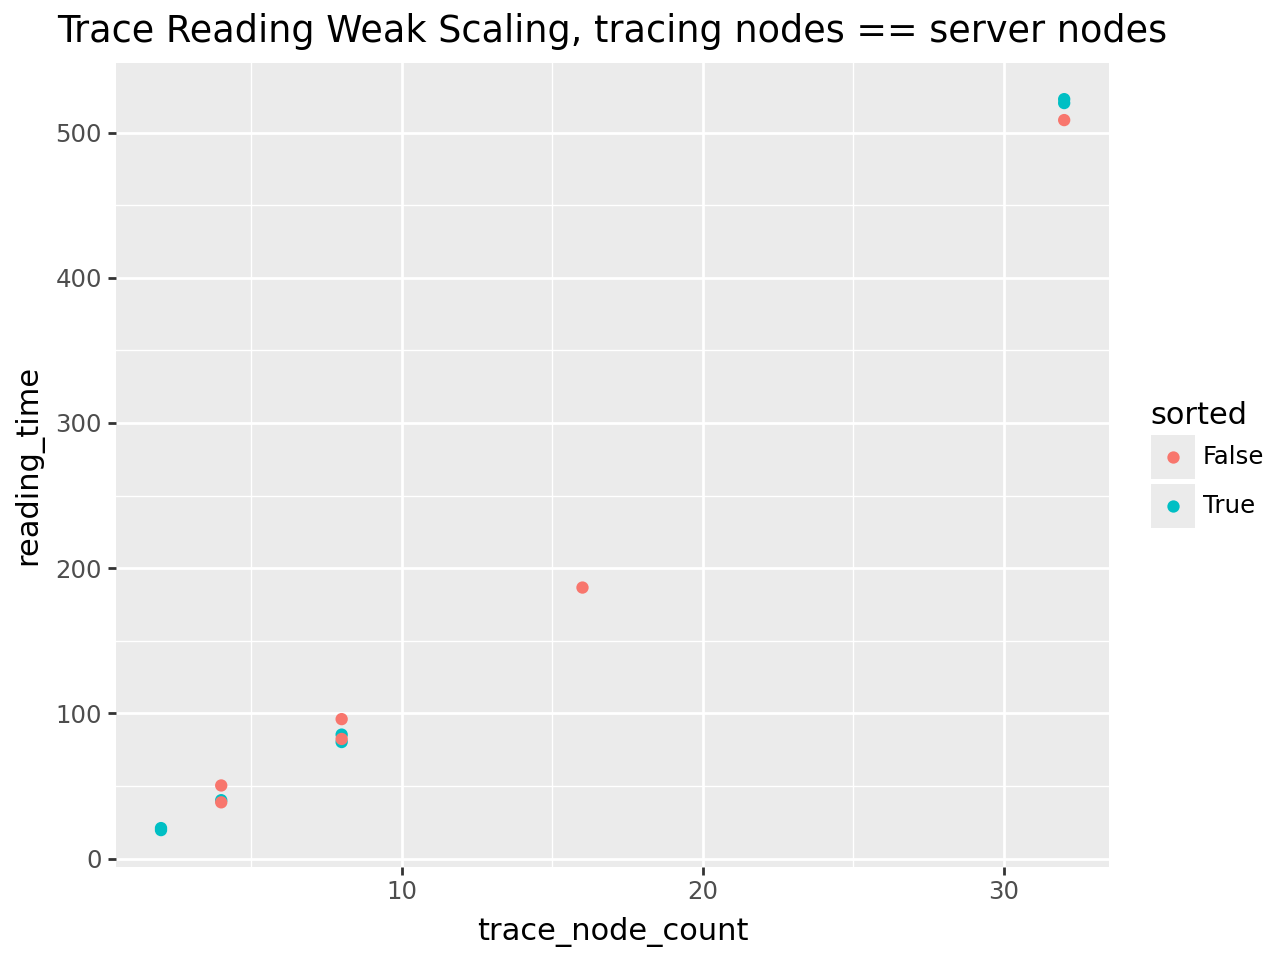

In [76]:
p = ggplot(results_df, aes(x='trace_node_count', y='reading_time', color='sorted'))
p += geom_point()
p += labs(title="Trace Reading Weak Scaling, tracing nodes == server nodes")
p

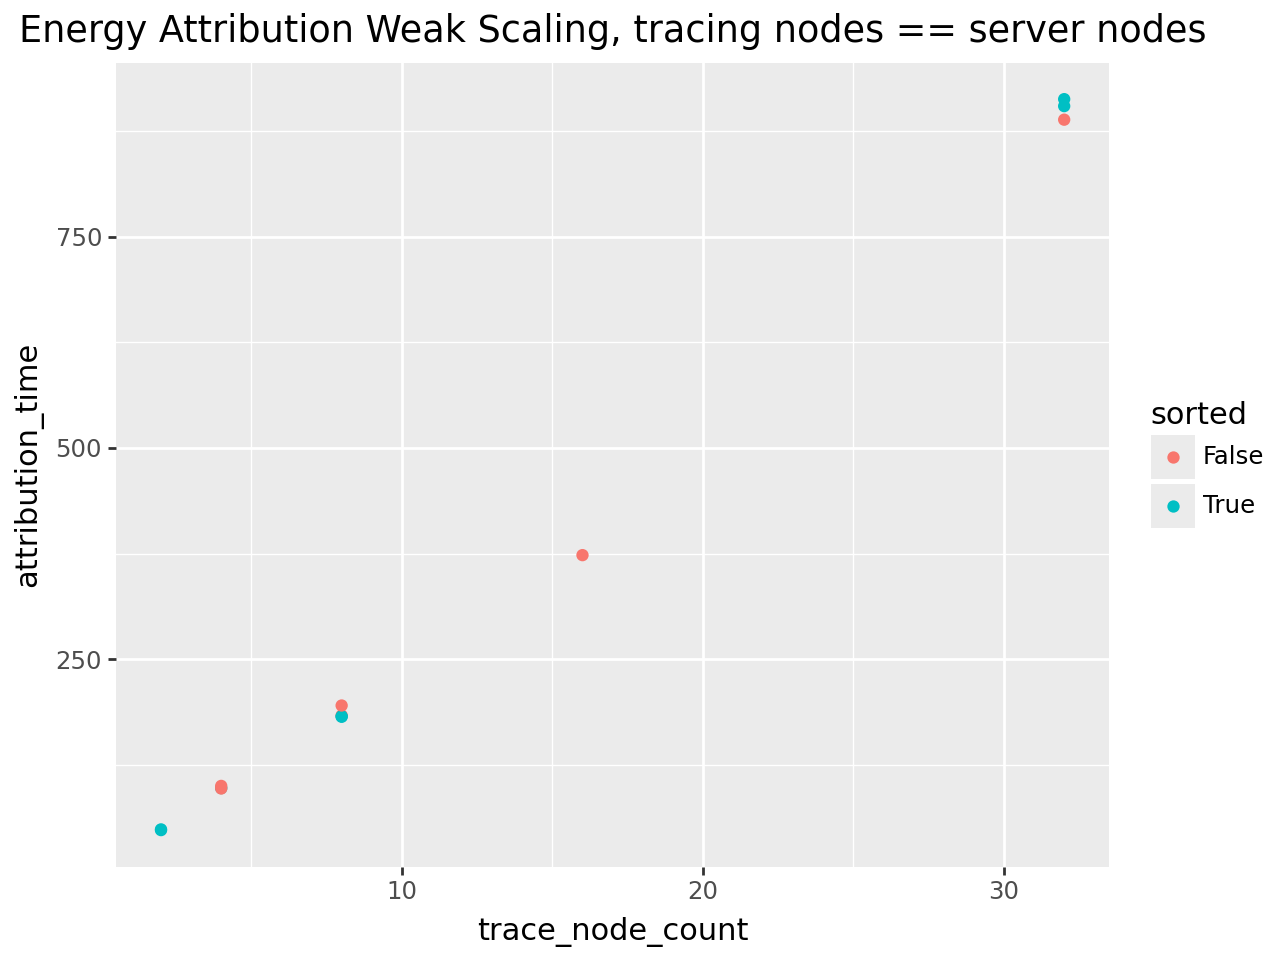

In [77]:
p = ggplot(results_df, aes(x='trace_node_count', y='attribution_time', color='sorted'))
p += geom_point()
p += labs(title="Energy Attribution Weak Scaling, tracing nodes == server nodes")
p

In [78]:
# Build paired timing rows for the same trace_node_count/trial_num with sorted vs unsorted runs
paired_columns = [
    'trace_node_count',
    'trial_num',
    'reading_time_sorted',
    'reading_time_unsorted',
    'attribution_time_sorted',
    'attribution_time_unsorted',
]

required_input_columns = [
    'trace_node_count',
    'trial_num',
    'sorted',
    'reading_time',
    'attribution_time',
]

missing_input_columns = [c for c in required_input_columns if c not in results_df.columns]

if missing_input_columns:
    print(f"Missing columns in results_df: {missing_input_columns}")
    paired_df = pd.DataFrame(columns=paired_columns)
else:
    tmp = results_df[required_input_columns].copy()

    # Normalize sorted values so we can reliably split into sorted/unsorted groups.
    def _is_sorted(v):
        if pd.isna(v):
            return False
        if isinstance(v, bool):
            return v
        if isinstance(v, (int, np.integer, float, np.floating)):
            return bool(v)
        return str(v).strip().lower() in {"true", "1", "yes", "y", "t"}

    tmp['sorted_norm'] = tmp['sorted'].apply(_is_sorted)

    read_wide = tmp.pivot_table(
        index=['trace_node_count', 'trial_num'],
        columns='sorted_norm',
        values='reading_time',
        aggfunc='first'
    )

    attr_wide = tmp.pivot_table(
        index=['trace_node_count', 'trial_num'],
        columns='sorted_norm',
        values='attribution_time',
        aggfunc='first'
    )

    # Ensure expected columns exist even if only one sorted state is present.
    read_wide = read_wide.rename(columns={True: 'reading_time_sorted', False: 'reading_time_unsorted'})
    attr_wide = attr_wide.rename(columns={True: 'attribution_time_sorted', False: 'attribution_time_unsorted'})

    for col in ['reading_time_sorted', 'reading_time_unsorted']:
        if col not in read_wide.columns:
            read_wide[col] = np.nan
    for col in ['attribution_time_sorted', 'attribution_time_unsorted']:
        if col not in attr_wide.columns:
            attr_wide[col] = np.nan

    paired_df = (
        read_wide[['reading_time_sorted', 'reading_time_unsorted']]
        .join(attr_wide[['attribution_time_sorted', 'attribution_time_unsorted']], how='outer')
        .reset_index()
        .sort_values(['trace_node_count', 'trial_num'])
        .reset_index(drop=True)
    )

    # Keep a stable output schema/order.
    for col in paired_columns:
        if col not in paired_df.columns:
            paired_df[col] = np.nan
    paired_df = paired_df[paired_columns]

paired_df['reading_time_difference_from_sorting'] = paired_df['reading_time_unsorted'] - paired_df['reading_time_sorted']
paired_df['attribution_time_difference_from_sorting'] = paired_df['attribution_time_unsorted'] - paired_df['attribution_time_sorted']
paired_df['reading_improvement_from_sorting'] = paired_df['reading_time_unsorted'] / paired_df['reading_time_sorted'] - 1
paired_df['attribution_improvement_from_sorting'] = paired_df['attribution_time_unsorted'] / paired_df['attribution_time_sorted'] - 1
paired_df

sorted_norm,trace_node_count,trial_num,reading_time_sorted,reading_time_unsorted,attribution_time_sorted,attribution_time_unsorted,reading_time_difference_from_sorting,attribution_time_difference_from_sorting,reading_improvement_from_sorting,attribution_improvement_from_sorting
0,2,0,21.053571,NaN,47.507369,NaN,NaN,NaN,NaN,NaN
1,2,1,19.674896,NaN,48.334277,NaN,NaN,NaN,NaN,NaN
2,4,0,NaN,38.797643,NaN,96.760854,NaN,NaN,NaN,NaN
3,4,1,40.265298,50.413709,97.299753,99.842148,10.148411,2.542395,0.252039,0.026130
4,8,0,85.435847,82.430921,181.723122,195.036065,-3.004927,13.312943,-0.035172,0.073259
5,8,1,80.323578,96.095221,182.301039,183.343640,15.771644,1.042601,0.196351,0.005719
6,16,1,NaN,186.685644,NaN,373.100616,NaN,NaN,NaN,NaN
7,32,0,520.308421,NaN,913.050887,NaN,NaN,NaN,NaN,NaN
8,32,1,522.998293,508.576757,904.804266,888.737227,-14.421536,-16.067038,-0.027575,-0.017757


/home/users/neth/.local/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 5 rows containing missing values.


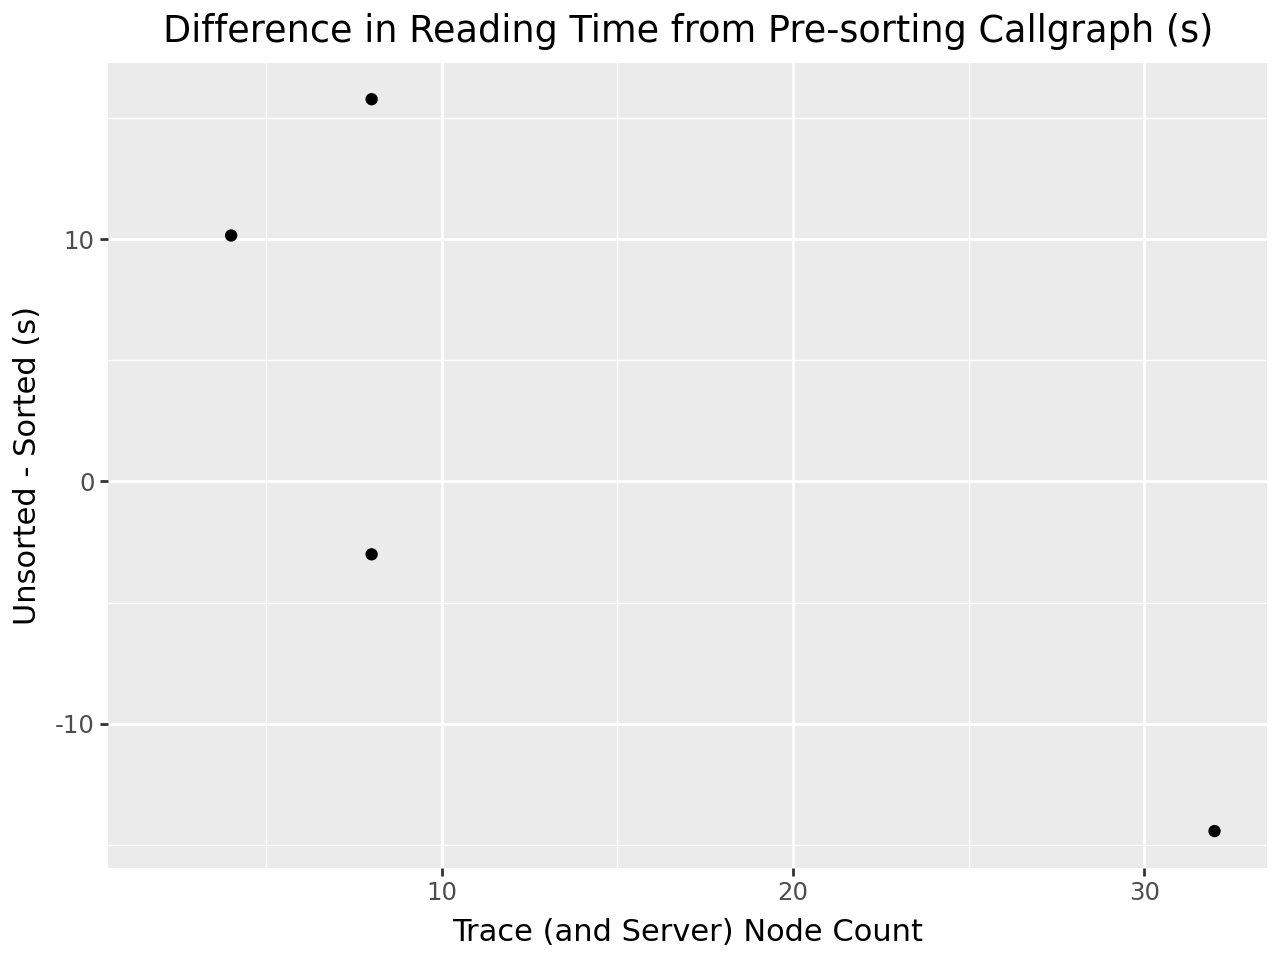

In [79]:
p = ggplot(paired_df, aes(x='trace_node_count', y='reading_time_difference_from_sorting'))
p += geom_point()
p += labs(title="Difference in Reading Time from Pre-sorting Callgraph (s)", y='Unsorted - Sorted (s)', x='Trace (and Server) Node Count')
p

/home/users/neth/.local/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 5 rows containing missing values.


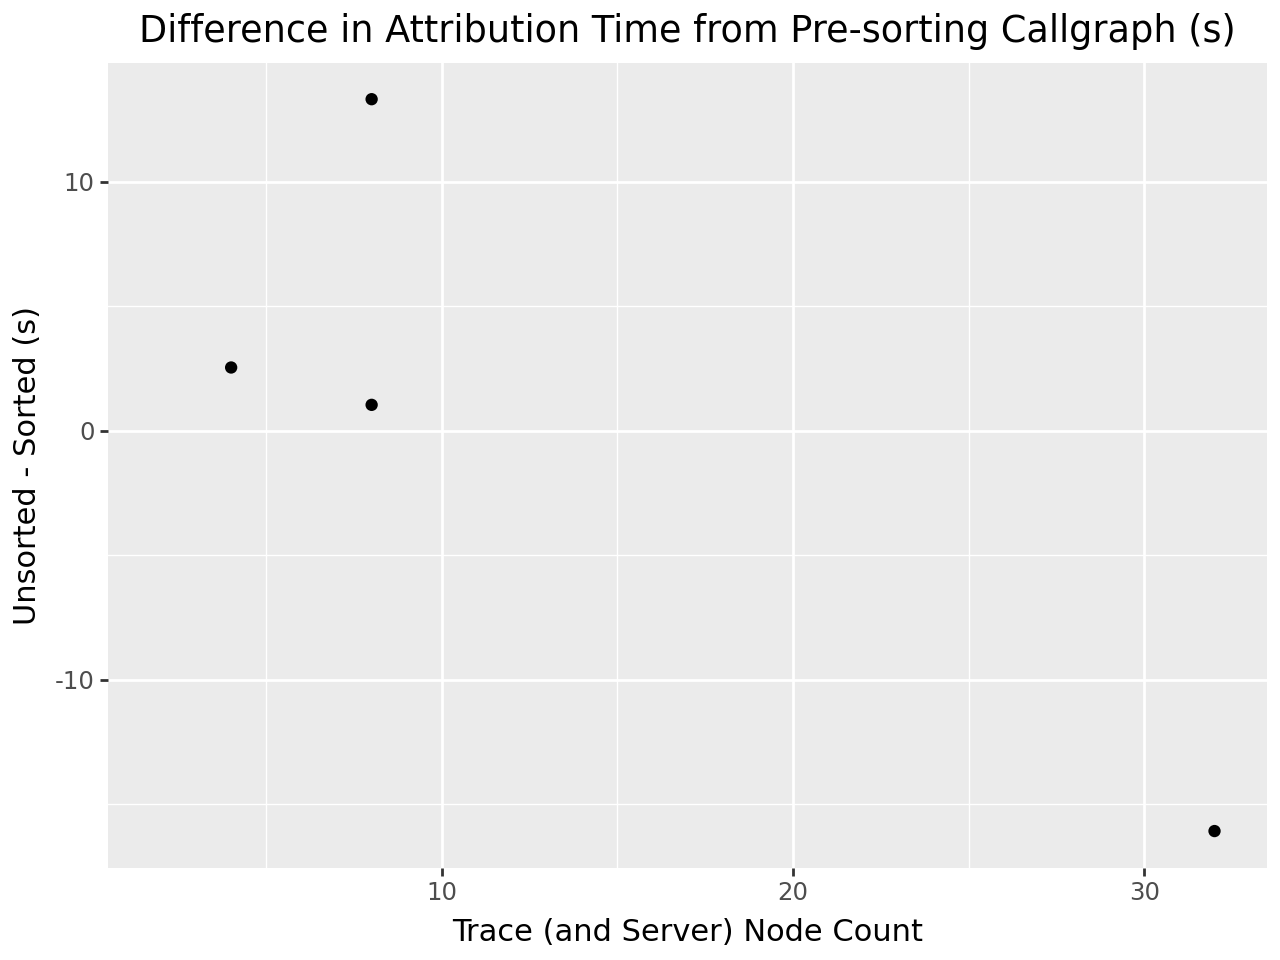

In [80]:
p = ggplot(paired_df, aes(x='trace_node_count', y='attribution_time_difference_from_sorting'))
p += geom_point()
p += labs(title="Difference in Attribution Time from Pre-sorting Callgraph (s)", y='Unsorted - Sorted (s)', x='Trace (and Server) Node Count')
p

/home/users/neth/.local/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 5 rows containing missing values.


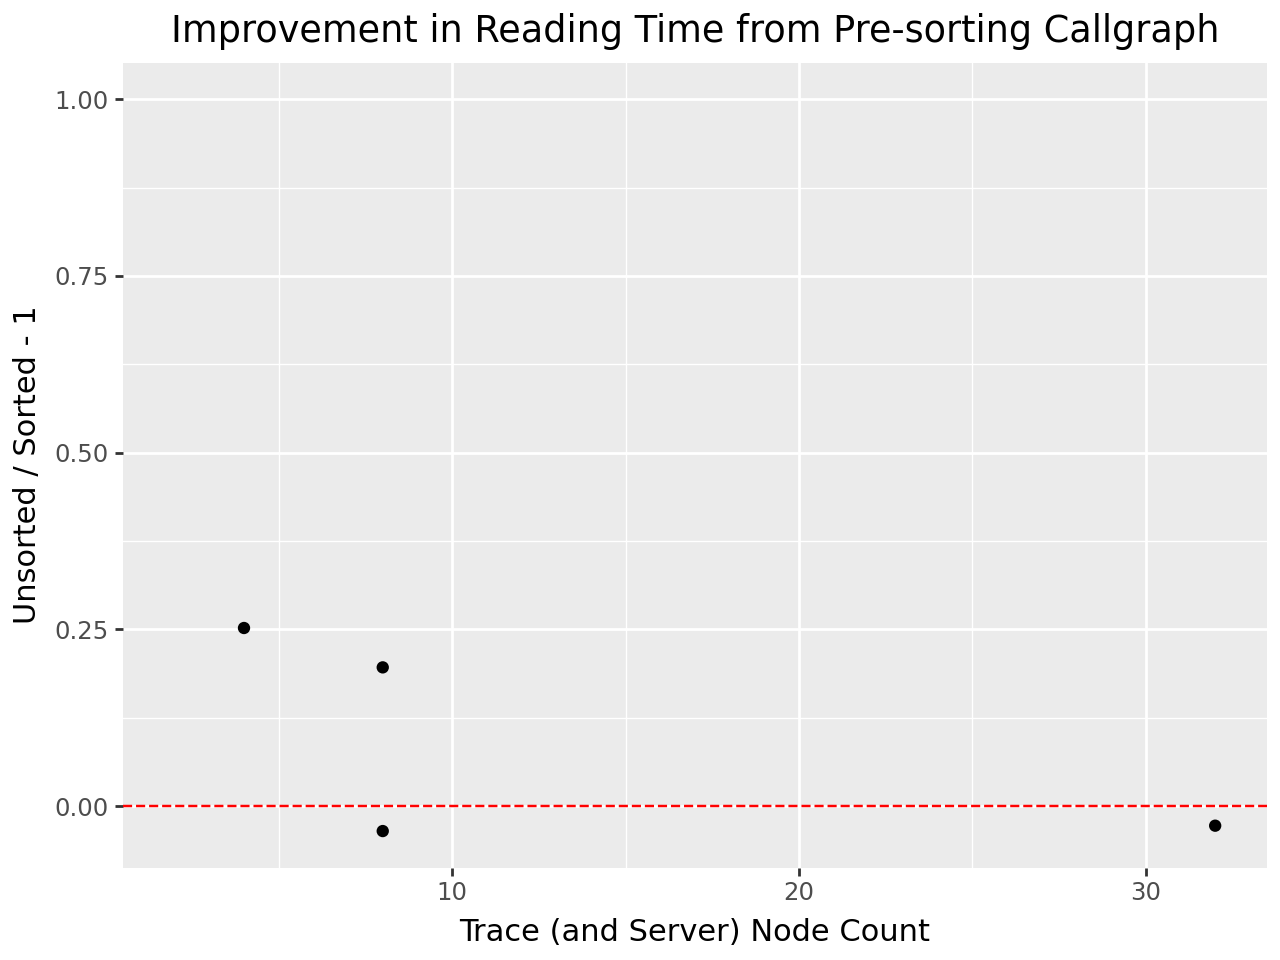

In [81]:
p = ggplot(paired_df, aes(x='trace_node_count', y='reading_improvement_from_sorting'))
p += geom_point()

p += scale_y_continuous(limits=(min(paired_df['reading_improvement_from_sorting'].min(), 0.0), max(paired_df['reading_improvement_from_sorting'].max() * 1.1, 1.0)))
p += labs(title="Improvement in Reading Time from Pre-sorting Callgraph", y='Unsorted / Sorted - 1', x='Trace (and Server) Node Count')
p += geom_hline(yintercept=0.0, linetype='dashed', color='red')
p

/home/users/neth/.local/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 5 rows containing missing values.


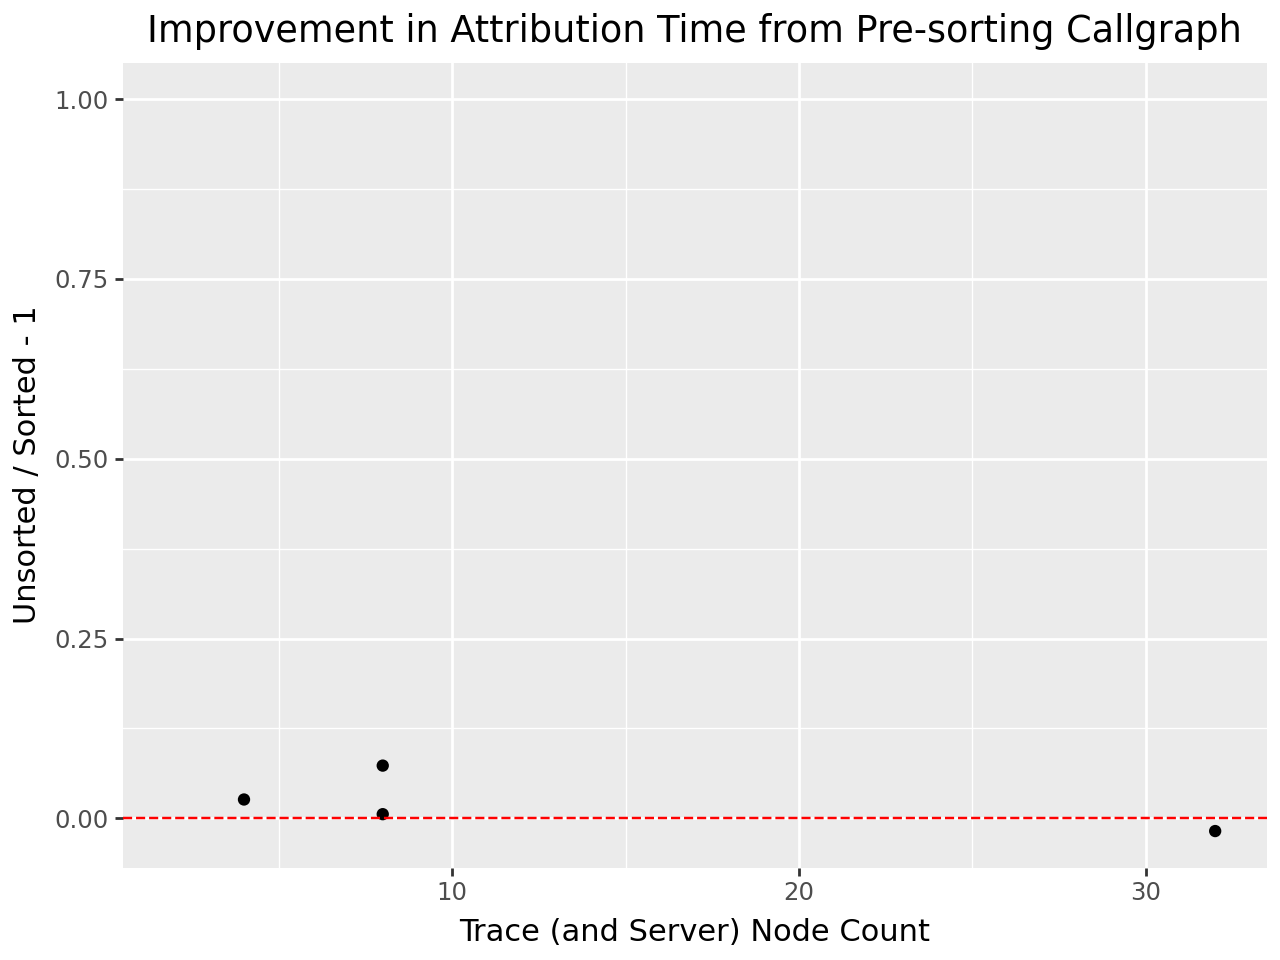

In [82]:
p = ggplot(paired_df, aes(x='trace_node_count', y='attribution_improvement_from_sorting'))
p += geom_point()
p += scale_y_continuous(limits=(min(paired_df['attribution_improvement_from_sorting'].min(), 0.0), max(paired_df['attribution_improvement_from_sorting'].max() * 1.1, 1.0)))
p += labs(title="Improvement in Attribution Time from Pre-sorting Callgraph", y='Unsorted / Sorted - 1', x='Trace (and Server) Node Count')
p += geom_hline(yintercept=0.0, linetype='dashed', color='red')
p